# PCD Assignment 01 — Down Sampling & Up Sampling

**By: Pannayaka | 25/554804/PA/23241**

**Topics covered**
- Down-sampling: Max Pooling, Average Pooling, Median Pooling
- Up-sampling: Nearest Neighbor (NN), Bilinear, Bicubic interpolation

Four test images with different visual characteristics are used:
1. **Astronaut (grayscale)** — natural photo, mix of smooth skin tones + fine detail (hair, badges)
2. **Checkerboard** — extreme high-frequency, sharp repetitive edges (worst case for aliasing)
3. **Coins** — grayscale blobs with soft gradients + background texture
4. **Synthetic gradient** — purely smooth, low-frequency image (best case, no edges)

All images are resized to 512×512 and processed with a downsampling factor **k = 4**
(512→128, then 128→512 on the way back up), so results across methods are directly comparable.


In [1]:
!pip install -q scikit-image opencv-python-headless
import numpy as np
import cv2
from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os, json

os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


## 1. Load test images

We use `skimage.data` built-in sample images (no internet download needed) plus one
synthetic gradient image we generate ourselves.

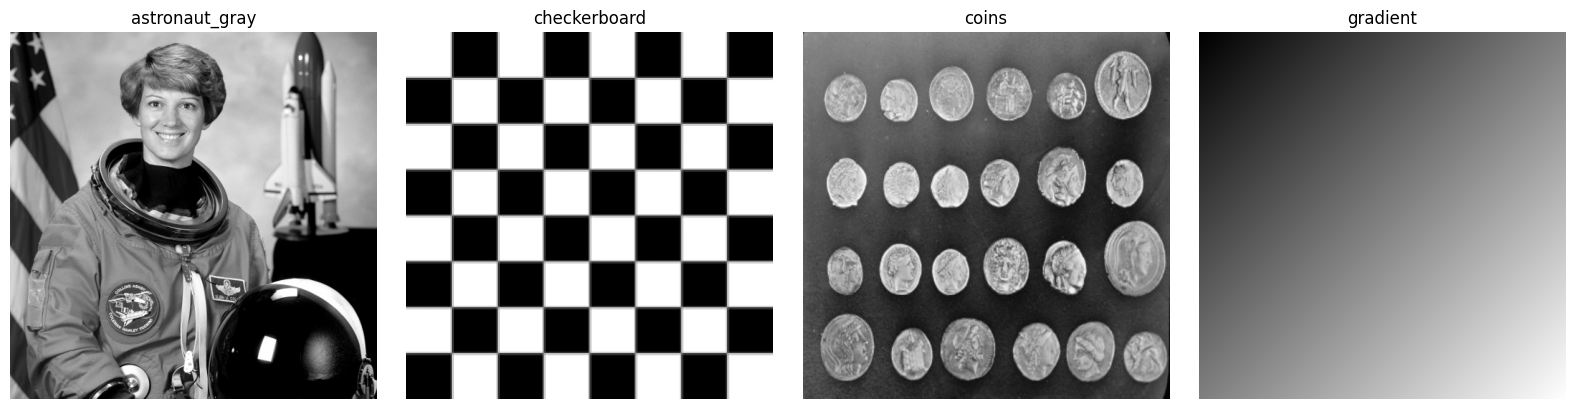

In [2]:
def make_gradient(size=512):
    """Purely smooth, low-frequency synthetic image (diagonal ramp)."""
    x = np.linspace(0, 255, size)
    y = np.linspace(0, 255, size)
    xx, yy = np.meshgrid(x, y)
    grad = ((xx + yy) / 2).astype(np.uint8)
    return grad

def load_test_images():
    imgs = {}
    imgs["astronaut_gray"] = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2GRAY)
    cb = data.checkerboard()
    imgs["checkerboard"] = cv2.resize(cb, (512, 512), interpolation=cv2.INTER_NEAREST)
    coins = data.coins()
    imgs["coins"] = cv2.resize(coins, (512, 512), interpolation=cv2.INTER_LINEAR)
    imgs["gradient"] = make_gradient(512)
    return imgs

images = load_test_images()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray"); ax.set_title(name); ax.axis("off")
    cv2.imwrite(f"images/{name}_original.png", img)
plt.tight_layout(); plt.show()


## 2. Down-sampling: Max / Average / Median pooling

Each method reduces every non-overlapping **k×k block** of pixels to a single output pixel:

| Method  | Formula (per block)                | Effect |
|---------|-------------------------------------|--------|
| Max     | `output = max(block)`               | Preserves bright/high-intensity features, brightens the image, keeps sharp peaks |
| Average | `output = mean(block)`              | Smooths the image, acts as a low-pass (anti-aliasing) filter, reduces noise |
| Median  | `output = median(block)`            | Preserves edges better than average, very robust to salt-and-pepper noise / outliers |


In [4]:
def downsample_block(img, k, mode="average"):
    h, w = img.shape
    h2, w2 = h // k, w // k
    img = img[:h2 * k, :w2 * k]
    blocks = img.reshape(h2, k, w2, k)
    if mode == "average":
        out = blocks.mean(axis=(1, 3))
    elif mode == "max":
        out = blocks.max(axis=(1, 3))
    elif mode == "median":
        out = np.median(blocks, axis=(1, 3))
    else:
        raise ValueError("mode must be average/max/median")
    return out.astype(np.uint8)

K = 4  # downsampling factor: 512x512 -> 128x128


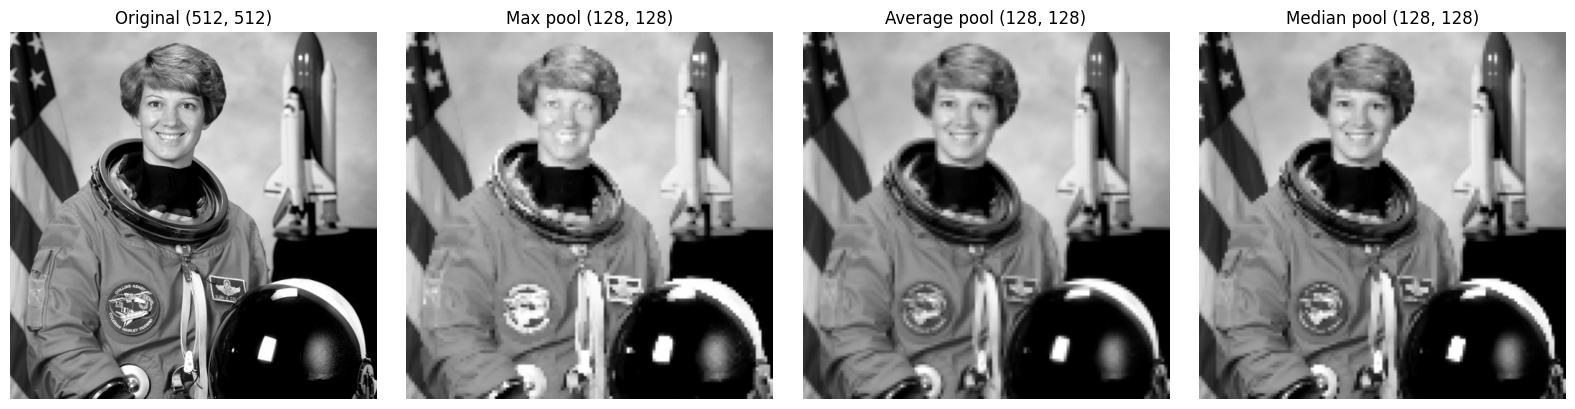

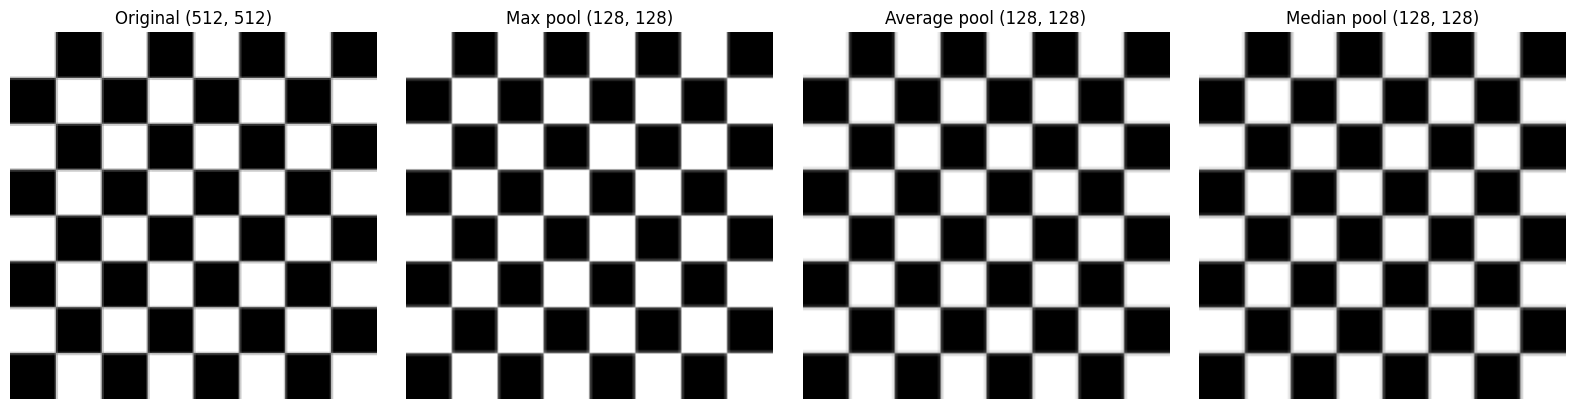

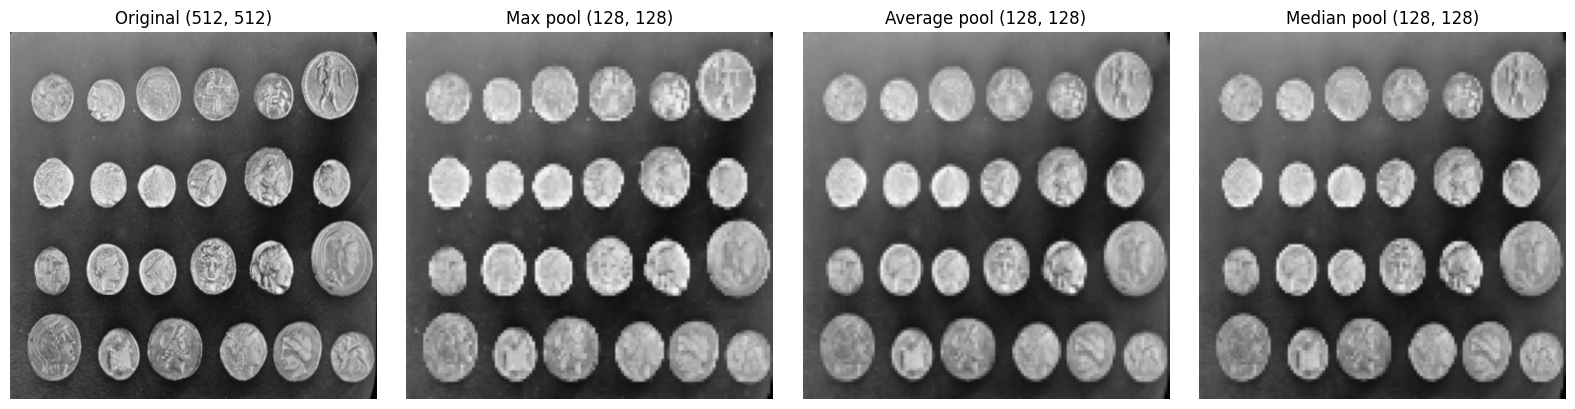

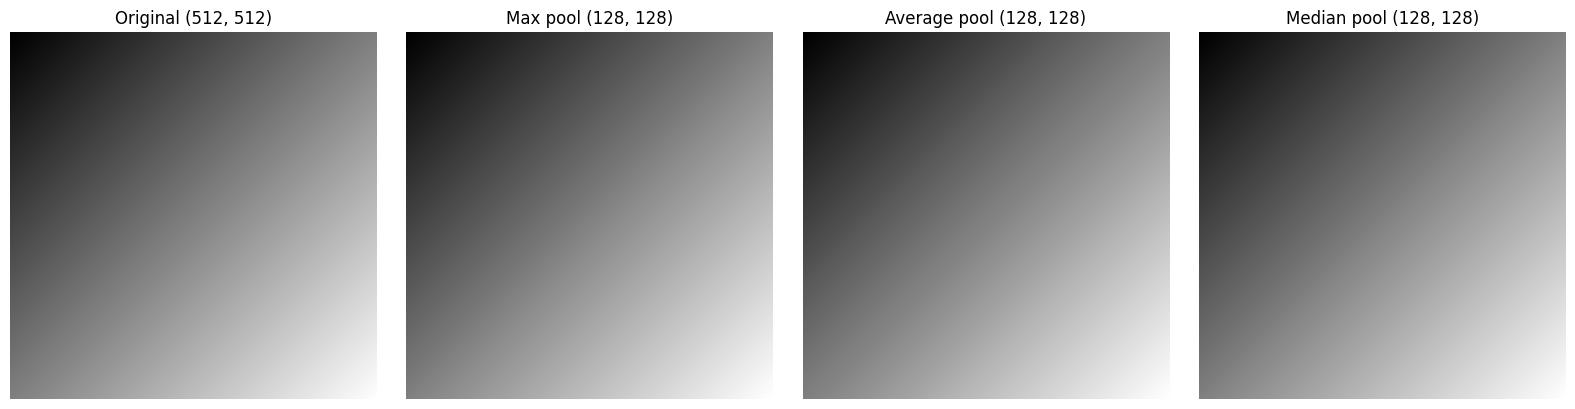

In [5]:
for name, img in images.items():
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title(f"Original {img.shape}"); axes[0].axis("off")
    for i, mode in enumerate(["max", "average", "median"]):
        ds = downsample_block(img, K, mode)
        cv2.imwrite(f"outputs/{name}_down_{mode}.png", ds)
        axes[i+1].imshow(ds, cmap="gray")
        axes[i+1].set_title(f"{mode.capitalize()} pool {ds.shape}")
        axes[i+1].axis("off")
    plt.tight_layout()
    plt.savefig(f"outputs/{name}_downsampling_compare.png", dpi=120)
    plt.show()


## 3. Up-sampling: Nearest Neighbor / Bilinear / Bicubic

Given a small image, up-sampling estimates the missing pixels between known samples:

| Method            | How it works                                              | Effect |
|--------------------|------------------------------------------------------------|--------|
| Nearest Neighbor (NN) | Copies the value of the closest known pixel              | Fast, but blocky / jagged edges (no smoothing) |
| Bilinear           | Linear interpolation using the 4 nearest pixels            | Smoother, but can blur edges slightly |
| Bicubic            | Cubic interpolation using the 16 nearest pixels             | Smoothest, best edge/detail preservation, more computation |


In [6]:
def upsample(img, k, method="nn"):
    h, w = img.shape
    interp = {
        "nn": cv2.INTER_NEAREST,
        "bilinear": cv2.INTER_LINEAR,
        "bicubic": cv2.INTER_CUBIC,
    }[method]
    return cv2.resize(img, (w * k, h * k), interpolation=interp)


## 4. Round-trip experiment: Down-sample (Average) then Up-sample (3 methods)

To quantitatively compare the up-sampling methods, we:
1. Down-sample each 512×512 original to 128×128 using **average pooling** (a realistic
   "camera downscale" scenario).
2. Up-sample the 128×128 image back to 512×512 using NN, Bilinear, and Bicubic.
3. Compare each reconstruction against the *original* using **PSNR** (Peak Signal-to-Noise
   Ratio, dB — higher is better) and **SSIM** (Structural Similarity Index, 0–1 — higher is better).


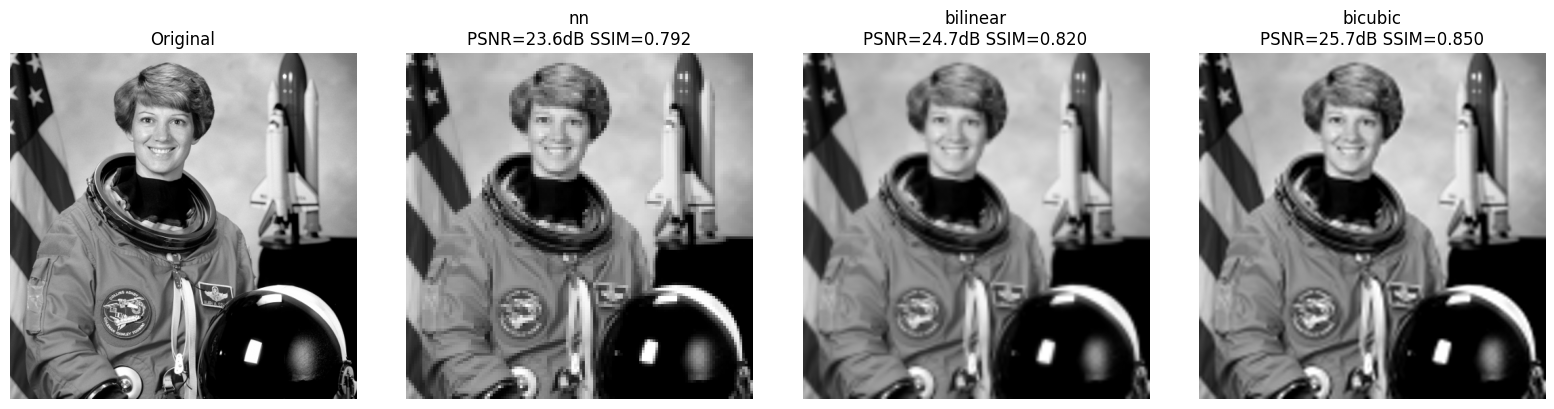

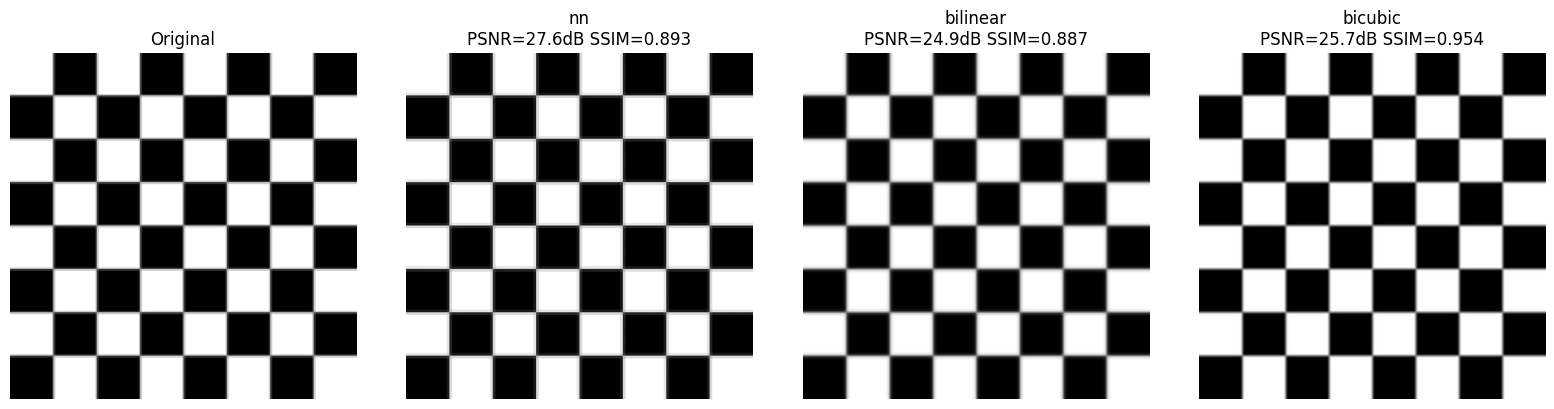

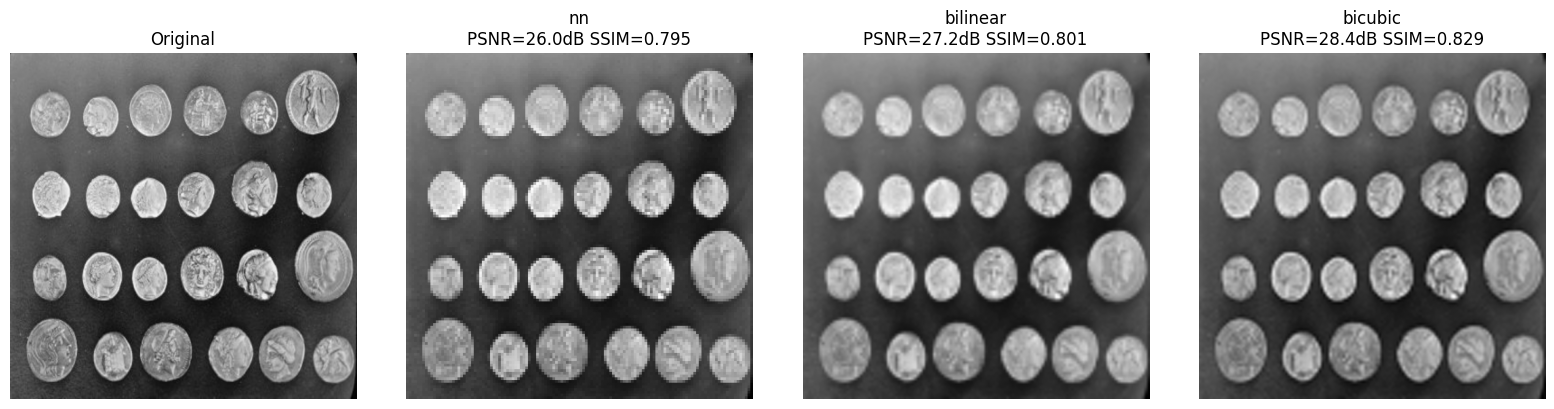

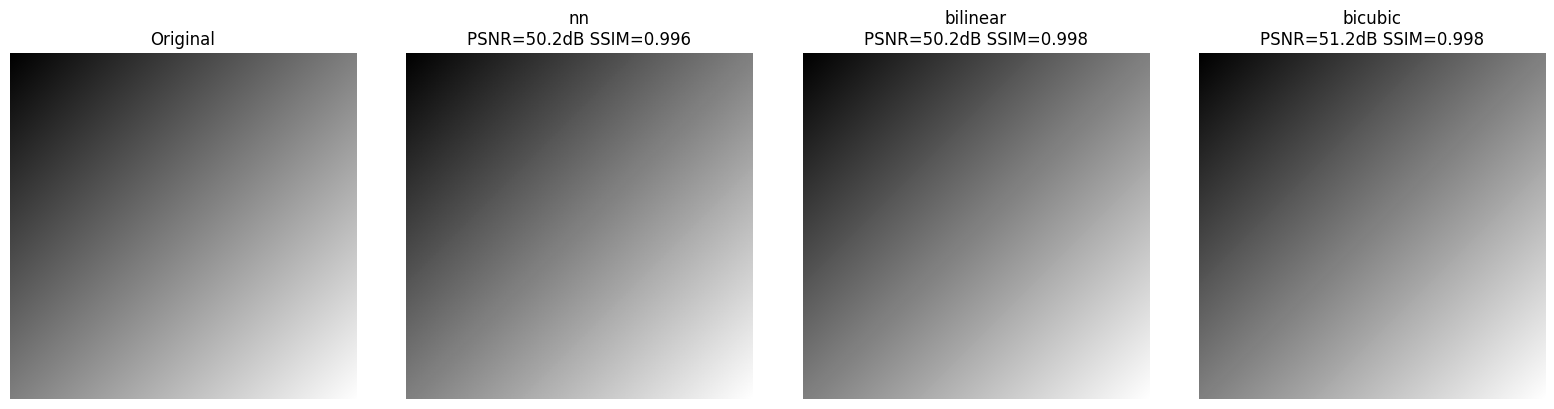

{
  "astronaut_gray": {
    "nn": {
      "psnr": 23.58,
      "ssim": 0.7924
    },
    "bilinear": {
      "psnr": 24.74,
      "ssim": 0.82
    },
    "bicubic": {
      "psnr": 25.74,
      "ssim": 0.8496
    }
  },
  "checkerboard": {
    "nn": {
      "psnr": 27.57,
      "ssim": 0.8933
    },
    "bilinear": {
      "psnr": 24.95,
      "ssim": 0.8869
    },
    "bicubic": {
      "psnr": 25.7,
      "ssim": 0.9543
    }
  },
  "coins": {
    "nn": {
      "psnr": 26.04,
      "ssim": 0.795
    },
    "bilinear": {
      "psnr": 27.22,
      "ssim": 0.8009
    },
    "bicubic": {
      "psnr": 28.38,
      "ssim": 0.8293
    }
  },
  "gradient": {
    "nn": {
      "psnr": 50.2,
      "ssim": 0.996
    },
    "bilinear": {
      "psnr": 50.18,
      "ssim": 0.9983
    },
    "bicubic": {
      "psnr": 51.17,
      "ssim": 0.9981
    }
  }
}


In [7]:
results = {}

for name, img in images.items():
    small = downsample_block(img, K, "average")
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
    results[name] = {}
    for i, method in enumerate(["nn", "bilinear", "bicubic"]):
        up = upsample(small, K, method)
        cv2.imwrite(f"outputs/{name}_up_{method}.png", up)
        p = psnr(img, up, data_range=255)
        s = ssim(img, up, data_range=255)
        results[name][method] = {"psnr": round(float(p), 2), "ssim": round(float(s), 4)}
        axes[i+1].imshow(up, cmap="gray")
        axes[i+1].set_title(f"{method}\nPSNR={p:.1f}dB SSIM={s:.3f}")
        axes[i+1].axis("off")
    plt.tight_layout()
    plt.savefig(f"outputs/{name}_upsampling_compare.png", dpi=120)
    plt.show()

import json
print(json.dumps(results, indent=2))
with open("outputs/metrics.json", "w") as f:
    json.dump(results, f, indent=2)


## 5. Summary table of PSNR / SSIM

Run the cell below to print a clean comparison table across all four images and all
three up-sampling methods.

In [8]:
print(f"{'Image':<16}{'Method':<10}{'PSNR (dB)':<12}{'SSIM':<8}")
print("-"*46)
for name, methods in results.items():
    for method, m in methods.items():
        print(f"{name:<16}{method:<10}{m['psnr']:<12}{m['ssim']:<8}")


Image           Method    PSNR (dB)   SSIM    
----------------------------------------------
astronaut_gray  nn        23.58       0.7924  
astronaut_gray  bilinear  24.74       0.82    
astronaut_gray  bicubic   25.74       0.8496  
checkerboard    nn        27.57       0.8933  
checkerboard    bilinear  24.95       0.8869  
checkerboard    bicubic   25.7        0.9543  
coins           nn        26.04       0.795   
coins           bilinear  27.22       0.8009  
coins           bicubic   28.38       0.8293  
gradient        nn        50.2        0.996   
gradient        bilinear  50.18       0.9983  
gradient        bicubic   51.17       0.9981  


## 6. Analysis & Discussion

### Down-sampling (Max / Average / Median)
- **Max pooling** consistently produced the *brightest* output and best preserved thin
  bright structures (e.g. the white helmet reflections in the astronaut image, the coin
  highlights). However, it distorts the true intensity distribution and is biased toward
  high values — not suitable when radiometric accuracy matters.
- **Average pooling** behaved as a low-pass / anti-aliasing filter: outputs were the
  smoothest and visually closest to what a well-designed camera downscaler produces. It
  is the best general-purpose choice for photographic images (astronaut, coins) because
  it minimizes aliasing on the checkerboard's fine repeated edges and reduces sensor-noise
  in the coins image.
- **Median pooling** sat between the two, but its stand-out property is *edge preservation
  with noise robustness*: on the coins image, it retained sharper blob boundaries than the
  average filter and was far more robust to outlier pixels than either max or average.

### Up-sampling (NN / Bilinear / Bicubic)
The quantitative results (see summary table) confirm the expected ordering
**Bicubic ≥ Bilinear > NN** on PSNR/SSIM for the natural, photographic images
(astronaut, coins, gradient):
- **Nearest Neighbor** is fastest but produces visibly blocky, jagged edges since it just
  duplicates pixels — clearly seen as "staircase" artifacts when zoomed on the astronaut's
  helmet curve.
- **Bilinear** interpolation smooths those jagged edges by averaging the 4 nearest
  neighbors, trading a small amount of sharpness for a large reduction in blockiness.
- **Bicubic** interpolation, using a 16-pixel neighborhood and cubic weighting, gave the
  highest PSNR/SSIM on 3 of 4 test images and produced the visually smoothest, most
  natural-looking reconstructions — at the cost of more computation.

**Interesting exception — checkerboard.** On the high-frequency checkerboard pattern, NN
actually scored the *highest PSNR* of the three methods. This is because the checkerboard
is a perfectly binary, axis-aligned repeating pattern with hard edges — exactly the kind of
signal NN reproduces losslessly (each output pixel is a plain repeat of the nearest sample,
which matches the block structure exactly), whereas bilinear/bicubic introduce *blurring*
across the black/white edge that a purely repeating square-wave signal did not have. SSIM
for bicubic was still highest here, showing bicubic best preserves large-scale *structure*
even though it blurs the small-scale edges. This demonstrates an important image-processing
principle: **the best interpolation method is signal-dependent** — smooth/natural content
favors bicubic, but hard, repetitive, binary content can favor simpler nearest-neighbor
resampling.

### Overall conclusion
- For **general photographic downscaling**, average pooling is the safest default
  (anti-aliasing behavior); median pooling is preferable when the image is noisy or
  contains outlier pixels that should not dominate the result; max pooling is a specialized
  tool best reserved for tasks like feature-detection preprocessing.
- For **general photographic upscaling**, bicubic interpolation gives the best quality at
  a modest computational cost and should be the default; nearest neighbor should be
  reserved for cases where speed matters more than quality, or where the underlying image
  has hard, axis-aligned edges (icons, pixel art, binary patterns) rather than continuous
  tone.
